In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap


In [ ]:
train_df = pd.read_csv("KDDTrain+.txt", header=None)
test_df  = pd.read_csv("KDDTest+.txt", header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


FileNotFoundError: [Errno 2] No such file or directory: 'KDDTrain+.txt'

In [ ]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df.columns = columns
test_df.columns = columns


NameError: name 'train_df' is not defined

In [ ]:
train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

df = pd.concat([train_df, test_df], axis=0)
df.reset_index(drop=True, inplace=True)

print("Combined dataset shape:", df.shape)


NameError: name 'train_df' is not defined

In [7]:
df = pd.concat([train_df, test_df], axis=0)
df.reset_index(drop=True, inplace=True)

print("Combined dataset shape:", df.shape)
df.head()


NameError: name 'train_df' is not defined

In [8]:
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

print(df['label'].value_counts())


NameError: name 'df' is not defined

In [9]:
categorical_cols = ['protocol_type', 'service', 'flag']

encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


NameError: name 'df' is not defined

In [10]:
X = df.drop("label", axis=1)
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)


NameError: name 'df' is not defined

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


NameError: name 'X' is not defined

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Model training completed")


NameError: name 'X_train' is not defined

In [13]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


NameError: name 'X_test' is not defined

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()


NameError: name 'y_test' is not defined

 99%|===================| 986/1000 [00:49<00:00]        

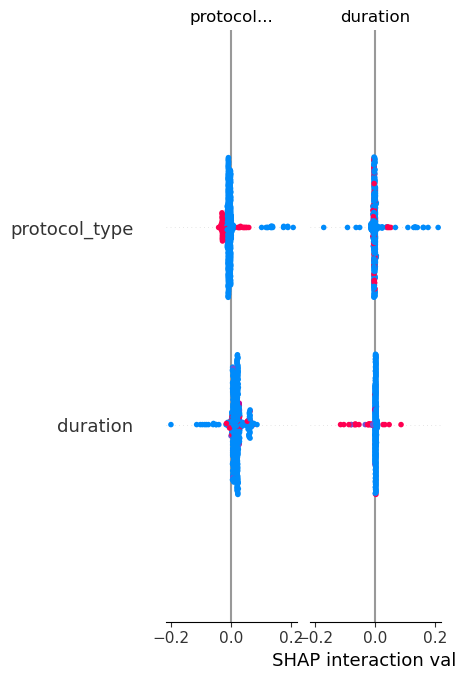

In [16]:
shap.initjs()

# USE SMALL SAMPLE (VERY IMPORTANT)
X_shap = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf_model,X_train)
shap_values = explainer.shap_values(X_shap)

# SHAP SUMMARY PLOT
shap.summary_plot(shap_values, X_shap)


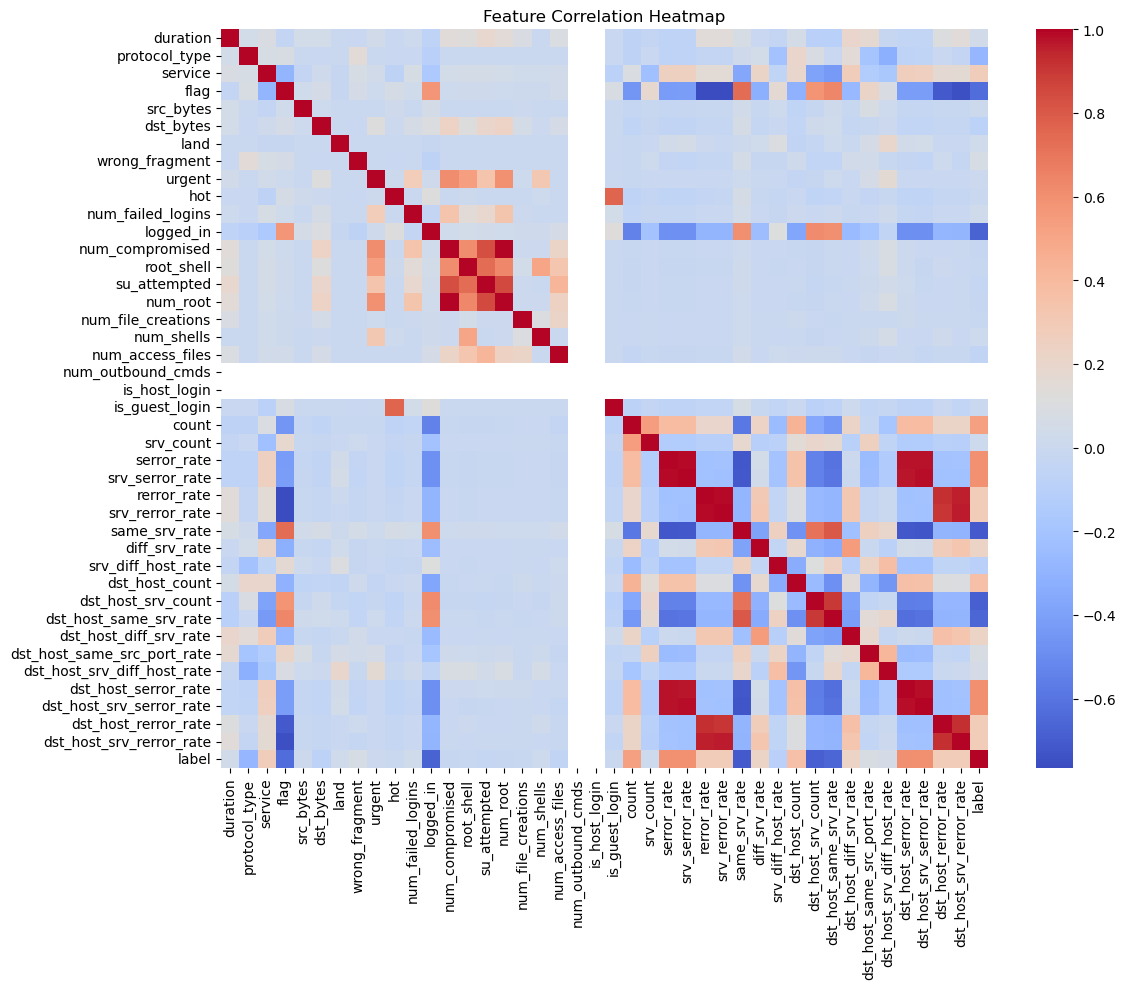

In [17]:
plt.figure(figsize=(12,10))

# sample to avoid memory issues
corr = df.sample(5000, random_state=42).corr()

sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
